## Paper Figure: Stylized Version (structured + failure-ready)

This is a second, independent figure cell. It keeps the original version untouched and adds:

- stronger visual design (custom palette + panel cards),
- explicit structure for panel-level control,
- baseline sample annotation hooks for common failure highlighting.

/tmp/ipykernel_1052661/491960775.py:809: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0.01, 0.03, 0.99, 0.94])


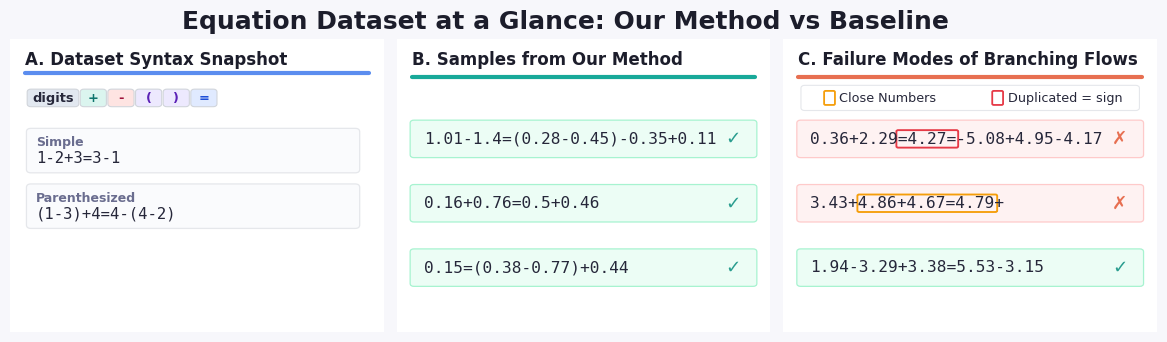

Saved: figures/dataset_overview_stylish.png
Saved: figures/dataset_overview_stylish.pdf
Our samples source: runs/parenthesis/depth8-constraint/itr_10000/samples.jsonl
Baseline source: branching_flows_samples/equations_l8_gen.jsonl


In [ ]:
from pathlib import Path
import json
import random
import ast
import re
import textwrap
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch
from matplotlib.font_manager import FontProperties

from evaluate_equations_parenthesis import parse_equation as _parse_equation_parenthesis

# -------------------------------------------------------------------
# Stylish figure config (edit this block to art-direct the figure)
# -------------------------------------------------------------------
STYLISH_CFG = {
    "seed": 15,
    "n_real_total": 5,
    "n_generated_each": 5,
    "ours_target_correct": 3,
    "baseline_target_examples": 3,
    "sample_max_chars": 30,
    "max_chars_per_equation": 34,
    "figsize": (14.8, 3.8),
    "dpi": 400,
    "equation_fontsize": 11.6,
    "equation_fontfamily": "DejaVu Sans Mono",
    "title": "Equation Dataset at a Glance: Our Method vs Baseline",
    "show_quality_badges": True,
    "show_failure_flags": True,
    "quality_tolerance": 0.5,
    "close_number_delta": 0.50,
    "highlight_issue_boxes": True,
    "save_png": "figures/dataset_overview_stylish.png",
    "save_pdf": "figures/dataset_overview_stylish.pdf",
    "palette": {
        "figure_bg": "#f7f7fb",
        "card_bg": "#ffffff",
        "card_edge": "#d9d7f8",
        "title": "#1c1d2b",
        "subtitle": "#4b4e6d",
        "body": "#26273a",
        "muted": "#6a6d8f",
        "accent_real": "#5b8def",
        "accent_ours": "#18a999",
        "accent_base": "#e76f51",
        "ok": "#2a9d8f",
        "warn": "#e76f51",
        "box_close": "#F59E0B",
        "box_double_equal": "#e63946",
    },
    "real_plain_candidates": [
        "data/equations_l5.jsonl",
        "data/equations_l8.jsonl",
    ],
    "ours_candidates": [
        "runs/parenthesis/depth8-constraint/itr_10000/samples.jsonl"
    ],
    "baseline_candidates": [
        "branching_flows_samples/equations_l8_gen.jsonl",
        "branching_flows_samples/equations_l10_gen.jsonl",
    ],
}


def _resolve_first_existing(candidates):
    for p in candidates:
        path = Path(p)
        if path.exists():
            return path
    return None


def _format_number(value):
    try:
        x = float(value)
    except (TypeError, ValueError):
        return str(value)
    if abs(x - round(x)) < 1e-6:
        return str(int(round(x)))
    return f"{x:.2f}".rstrip("0").rstrip(".")


def _symbols_to_equation(symbols):
    if not symbols:
        return ""
    return "".join(str(tok) for tok in symbols).strip()


def _numbers_symbols_to_equation(numbers, symbols):
    if not isinstance(symbols, list) or not symbols:
        return ""
    if not isinstance(numbers, list):
        numbers = []
    out = []
    n_idx = 0
    for tok in symbols:
        tok = str(tok)
        if tok in {"(", ")"}:
            out.append(tok)
            continue
        if n_idx < len(numbers):
            out.append(_format_number(numbers[n_idx]))
            n_idx += 1
        out.append(tok)
    return "".join(out).strip()


def _load_equations_auto(path):
    suffix = path.suffix.lower()
    if suffix == ".jsonl":
        eqs = []
        with path.open("r") as f:
            for line in f:
                line = line.strip()
                if not line:
                    continue
                item = json.loads(line)
                if "equation" in item and isinstance(item["equation"], str):
                    eq = item["equation"].strip()
                elif "numbers" in item and "symbols" in item:
                    eq = _numbers_symbols_to_equation(item["numbers"], item["symbols"])
                elif "symbols" in item:
                    eq = _symbols_to_equation(item["symbols"])
                else:
                    continue
                if eq:
                    eqs.append(eq)
        return eqs

    if suffix == ".json":
        data = json.loads(path.read_text())
        eqs = []
        if isinstance(data, list):
            for item in data:
                if not isinstance(item, dict):
                    continue
                if "equation" in item:
                    eqs.append(str(item["equation"]).strip())
                elif "numbers" in item and "symbols" in item:
                    eqs.append(_numbers_symbols_to_equation(item["numbers"], item["symbols"]))
                elif "symbols" in item:
                    eqs.append(_symbols_to_equation(item["symbols"]))
            return [e for e in eqs if e]
        if isinstance(data, dict) and "molecules" in data:
            raise ValueError(f"{path} is QM9 molecule output, not equation data.")
        return [e for e in eqs if e]

    raise ValueError(f"Unsupported file type: {path}")


def _load_jsonl_records(path: Path):
    records = []
    with path.open("r", encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            records.append(json.loads(line))
    return records


def _equation_abs_error_parenthesis(item):
    symbols = item.get("symbols")
    positions = item.get("positions", item.get("numbers", []))
    if not symbols or not positions:
        return None
    if not isinstance(symbols, list):
        symbols = list(symbols)
    try:
        left, right = _parse_equation_parenthesis(
            symbols, positions, ignore_trailing_ops=True
        )
    except Exception:
        return None
    return abs(float(left) - float(right))


def _pick_curated_ours_parenthesis(ours_samples, cfg, rng):
    """Pick display equations for panel B using the same parser as evaluate_equations_parenthesis."""
    max_chars = cfg["sample_max_chars"]
    tol = cfg["quality_tolerance"]
    ours_target = cfg.get("ours_target_correct", 3)

    rows = []
    seen_eq = set()
    for item in ours_samples:
        eq = _numbers_symbols_to_equation(
            item.get("numbers", []), item.get("symbols", [])
        )
        if not eq:
            continue
        clean = _clean_equation_display(eq)
        if "()" in clean or _has_singleton_paren_wrapped_number(clean):
            continue
        disp = _normalize_paren_display(clean)
        if disp in seen_eq:
            continue
        seen_eq.add(disp)
        err = _equation_abs_error_parenthesis(item)
        rows.append((disp, err))

    err_by_eq = dict(rows)
    short_rows = [(e, err) for e, err in rows if len(e) <= max_chars]
    correct = [(e, err) for e, err in short_rows if err is not None and err <= tol]

    if len(correct) >= ours_target:
        picked = rng.sample(correct, ours_target)
        return [p[0] for p in picked], [p[1] for p in picked]

    ours_panel = [e for e, _ in correct]
    errs_out = [err for _, err in correct]
    need = ours_target - len(ours_panel)
    if need > 0:
        pool_eqs = [e for e, _ in short_rows if e not in set(ours_panel)]
        extra = _sample_short_equations(pool_eqs, need, rng, max_chars)
        for e in extra:
            ours_panel.append(e)
            errs_out.append(err_by_eq.get(e))

    if len(errs_out) < len(ours_panel):
        errs_out.extend([None] * (len(ours_panel) - len(errs_out)))
    return ours_panel[:ours_target], errs_out[:ours_target]


def _sample_short_equations(items, n, rng, max_chars):
    if not items:
        return []
    dedup = list(dict.fromkeys(items))
    short_pool = [eq for eq in dedup if len(eq) <= max_chars]
    if len(short_pool) >= n:
        return rng.sample(short_pool, n)
    remain = sorted([eq for eq in dedup if eq not in set(short_pool)], key=len)
    return short_pool + remain[: max(0, n - len(short_pool))]


def _clean_equation_display(eq):
    return eq.strip().rstrip(".")


def _fix_trailing_binop_before_close(s: str) -> str:
    """Move a dangling + or - immediately before ')' to after it, e.g. (x+y-)z -> (x+y)-z.

    Only rewrites innermost groups whose body contains no nested '(', so nested structure is fixed inside-out.
    """
    changed = True
    while changed:
        changed = False
        i = 0
        while i < len(s):
            if s[i] != ")":
                i += 1
                continue
            depth = 1
            j = i - 1
            while j >= 0 and depth:
                if s[j] == ")":
                    depth += 1
                elif s[j] == "(":
                    depth -= 1
                if depth == 0:
                    break
                j -= 1
            if j < 0:
                i += 1
                continue
            inner = s[j + 1 : i]
            if inner and inner[-1] in "+-" and "(" not in inner:
                op = inner[-1]
                core = inner[:-1]
                s = s[:j] + f"({core}){op}" + s[i + 1 :]
                changed = True
                break
            i += 1
    return s


def _has_singleton_paren_wrapped_number(eq: str) -> bool:
    """True if eq has a parenthetical group that is only a single numeric literal, e.g. (3) or (-1.5)."""
    for m in re.finditer(r"\(([^()]*)\)", eq):
        inner = m.group(1).strip()
        if re.fullmatch(r"-?\d+(?:\.\d+)?", inner):
            return True
    return False


def _normalize_paren_display(s: str) -> str:
    """Fix dangling ops before ')', drop empty (), unwrap (numeric) for cleaner infix display."""
    s = _fix_trailing_binop_before_close(s)
    while "()" in s:
        s = s.replace("()", "")
    num_only = re.compile(r"\(\s*(-?\d+(?:\.\d+)?)\s*\)")
    while True:
        s2, n = num_only.subn(r"\1", s)
        if n == 0:
            break
        s = s2
    return s

def _truncate(text, max_chars):
    if len(text) <= max_chars:
        return text
    return text[: max_chars - 3] + "..."


def _truncate_spans(spans, visible_len):
    out = []
    for start, end in spans:
        if start >= visible_len:
            continue
        out.append((start, min(end, visible_len)))
    return out


def _merge_spans(spans, gap=0):
    if not spans:
        return []
    spans_sorted = sorted(spans, key=lambda s: (s[0], s[1]))
    merged = [list(spans_sorted[0])]
    for start, end in spans_sorted[1:]:
        prev = merged[-1]
        if start <= prev[1] + gap:
            prev[1] = max(prev[1], end)
        else:
            merged.append([start, end])
    return [(s, e) for s, e in merged]


def _find_issue_spans(eq, close_number_delta=0.20):
    close_spans = []
    double_eq_spans = []

    # 1) very close neighboring numbers -> contiguous region across both numbers
    num_matches = list(re.finditer(r"-?\d+(?:\.\d+)?", eq))
    for i in range(len(num_matches) - 1):
        a = float(num_matches[i].group())
        b = float(num_matches[i + 1].group())
        if abs(a - b) <= close_number_delta:
            close_spans.append((num_matches[i].start(), num_matches[i + 1].end()))

    # 2a) literal repeated equals: "==", "===", ...
    for m in re.finditer(r"={2,}", eq):
        double_eq_spans.append(m.span())

    # 2b) multiple equals separated by text: e.g., "1-2=3=4"
    eq_positions = [idx for idx, ch in enumerate(eq) if ch == "="]
    if len(eq_positions) >= 2 and not double_eq_spans:
        double_eq_spans.append((eq_positions[0], eq_positions[-1] + 1))

    return {
        "close_numbers": _merge_spans(close_spans, gap=1),
        "double_equal": _merge_spans(double_eq_spans, gap=0),
    }


def _safe_eval_arith(expr):
    node = ast.parse(expr, mode="eval")

    def _eval(n):
        if isinstance(n, ast.Expression):
            return _eval(n.body)
        if isinstance(n, ast.Constant) and isinstance(n.value, (int, float)):
            return float(n.value)
        if isinstance(n, ast.UnaryOp) and isinstance(n.op, (ast.UAdd, ast.USub)):
            val = _eval(n.operand)
            return val if isinstance(n.op, ast.UAdd) else -val
        if isinstance(n, ast.BinOp) and isinstance(n.op, (ast.Add, ast.Sub, ast.Mult)):
            left = _eval(n.left)
            right = _eval(n.right)
            if isinstance(n.op, ast.Add):
                return left + right
            if isinstance(n.op, ast.Sub):
                return left - right
            return left * right
        raise ValueError("Unsupported expression")

    return _eval(node)


def _equation_error(eq):
    if "=" not in eq:
        return None
    clean = eq.strip().rstrip(".")
    left, right = clean.split("=", 1)
    if not left.strip() or not right.strip():
        return None
    try:
        lval = _safe_eval_arith(left)
        rval = _safe_eval_arith(right)
    except Exception:
        return None
    return abs(lval - rval)


def _extract_numbers(eq):
    return [float(m.group()) for m in re.finditer(r"-?\d+(?:\.\d+)?", eq)]


def _has_double_equal(eq):
    return eq.count("=") >= 2 or "==" in eq


def _has_long_close_sequence(eq, delta=0.20, min_run=3):
    nums = _extract_numbers(eq)
    if len(nums) < min_run:
        return False
    run = 1
    for i in range(len(nums) - 1):
        if abs(nums[i] - nums[i + 1]) <= delta:
            run += 1
            if run >= min_run:
                return True
        else:
            run = 1
    return False


def _is_correct_equation(eq, tolerance=0.25):
    clean = _clean_equation_display(eq)
    if clean.count("=") != 1:
        return False
    if clean.count("(") != clean.count(")"):
        return False
    if clean.endswith(("+", "-", "*", "=")):
        return False
    err = _equation_error(clean)
    return err is not None and err <= tolerance


def _pick_curated_baseline(baseline, cfg, rng):
    max_chars = cfg["sample_max_chars"]
    tol = cfg["quality_tolerance"]
    delta = cfg["close_number_delta"]

    baseline_dedup = [eq for eq in dict.fromkeys(baseline) if len(_clean_equation_display(eq)) <= max_chars]
    baseline_panel = []

    def _pick_first(predicate):
        for eq in baseline_dedup:
            if eq in baseline_panel:
                continue
            if predicate(eq):
                baseline_panel.append(eq)
                return

    _pick_first(lambda eq: _has_double_equal(_clean_equation_display(eq)))
    _pick_first(lambda eq: _has_long_close_sequence(_clean_equation_display(eq), delta=delta, min_run=3))
    _pick_first(lambda eq: _is_correct_equation(eq, tolerance=tol))

    target = cfg.get("baseline_target_examples", 3)
    if len(baseline_panel) < target:
        fillers = [eq for eq in baseline_dedup if eq not in baseline_panel]
        baseline_panel.extend(fillers[: target - len(baseline_panel)])

    return baseline_panel[:target]


def _detect_baseline_issues(eq):
    issues = []
    if "=" not in eq:
        issues.append("no_equal")
    if eq.count("(") != eq.count(")"):
        issues.append("unbalanced_paren")

    # Incomplete tails like "3.8-" or "2.9+" are common model failures.
    tail = eq.strip()
    if tail.endswith(("+", "-", "*", "=")):
        issues.append("incomplete_tail")

    if eq.count("=") >= 2:
        issues.append("double_equal")

    return issues


def _add_card(ax, face, edge):
    card = FancyBboxPatch(
        (0.0, 0.0),
        1.0,
        1.0,
        boxstyle="round,pad=0.02,rounding_size=0.03",
        transform=ax.transAxes,
        linewidth=1.4,
        edgecolor=edge,
        facecolor=face,
        zorder=0,
    )
    ax.add_patch(card)


def _draw_list_panel(
    ax,
    title,
    equations,
    palette,
    title_accent,
    max_chars=34,
    show_failure_flags=False,
    show_quality_badges=False,
    quality_tolerance=0.25,
    highlight_issue_boxes=True,
    close_number_delta=0.20,
    reserve_top_space=False,
    show_success_marks=False,
    equation_fontsize=11.6,
    equation_fontfamily="DejaVu Sans Mono",
    subtitle=None,
    quality_errors=None,
):
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.axis("off")
    _add_card(ax, palette["card_bg"], palette["card_edge"])

    ax.text(0.04, 0.93, title, ha="left", va="center", fontsize=12, fontweight="bold", color=palette["title"])
    ax.plot([0.04, 0.96], [0.872, 0.872], lw=3, color=title_accent, solid_capstyle="round")

    if not equations:
        ax.text(0.5, 0.5, "No equations found", ha="center", va="center", fontsize=11, color=palette["muted"])
        return

    show_issue_legend = bool(show_failure_flags)
    if show_issue_legend:
        # Centered horizontal legend in a dedicated strip.
        strip = FancyBboxPatch(
            (0.05, 0.76),
            0.90,
            0.08,
            boxstyle="round,pad=0.003,rounding_size=0.010",
            linewidth=0.8,
            edgecolor="#E5E7EB",
            facecolor="#FFFFFF",
            transform=ax.transAxes,
        )
        ax.add_patch(strip)

        leg_y = 0.80
        box_w = 0.027
        box_h = 0.046
        first_x = 0.11
        second_x = 0.56
        label_dx = 0.040

        box_close = FancyBboxPatch(
            (first_x, leg_y - box_h / 2),
            box_w,
            box_h,
            boxstyle="round,pad=0.001,rounding_size=0.004",
            linewidth=1.3,
            edgecolor=palette["box_close"],
            facecolor="none",
            transform=ax.transAxes,
        )
        ax.add_patch(box_close)
        ax.text(first_x + label_dx, leg_y, "Close Numbers", ha="left", va="center", fontsize=9.2, color=palette["body"])

        box_eq = FancyBboxPatch(
            (second_x, leg_y - box_h / 2),
            box_w,
            box_h,
            boxstyle="round,pad=0.001,rounding_size=0.004",
            linewidth=1.3,
            edgecolor=palette["box_double_equal"],
            facecolor="none",
            transform=ax.transAxes,
        )
        ax.add_patch(box_eq)
        ax.text(second_x + label_dx, leg_y, "Duplicated = sign", ha="left", va="center", fontsize=9.2, color=palette["body"])

    y0 = 0.66 if (show_issue_legend or reserve_top_space) else 0.80
    y_bottom = 0.22
    if len(equations) <= 1:
        y_positions = [0.5 * (y0 + y_bottom)]
    else:
        ystep = (y0 - y_bottom) / (len(equations) - 1)
        y_positions = [y0 - i * ystep for i in range(len(equations))]

    text_fontsize = equation_fontsize
    text_family = equation_fontfamily

    # Use renderer-measured glyph widths for accurate highlight placement.
    ax.figure.canvas.draw()
    renderer = ax.figure.canvas.get_renderer()
    fp = FontProperties(family=text_family, size=text_fontsize)

    def _px_to_ax_dx(px):
        p0 = ax.transAxes.inverted().transform((0, 0))
        p1 = ax.transAxes.inverted().transform((px, 0))
        return p1[0] - p0[0]

    def _px_to_ax_dy(px):
        p0 = ax.transAxes.inverted().transform((0, 0))
        p1 = ax.transAxes.inverted().transform((0, px))
        return p1[1] - p0[1]

    for i, eq in enumerate(equations):
        y = y_positions[i]
        eq_clean = _clean_equation_display(eq)
        eq_display = _normalize_paren_display(eq_clean)
        text = _truncate(eq_display, max_chars)

        issue_found = False

        if show_quality_badges:
            if quality_errors is not None and i < len(quality_errors):
                err = quality_errors[i]
            else:
                err = _equation_error(eq_clean)
            if err is None or err > quality_tolerance:
                issue_found = True

        if show_failure_flags and _detect_baseline_issues(eq_clean):
            issue_found = True

        # Row micro-card with semantic color (replaces VALID/ISSUE text badges).
        row_h = 0.12 if len(equations) <= 3 else 0.10
        if issue_found:
            row_face = "#FEF2F2"
            row_edge = "#FECACA"
        elif show_success_marks:
            row_face = "#ECFDF5"
            row_edge = "#A7F3D0"
        else:
            row_face = "#F8FAFC"
            row_edge = "#E5E7EB"

        row_card = FancyBboxPatch(
            (0.04, y - row_h / 2),
            0.92,
            row_h,
            boxstyle="round,pad=0.004,rounding_size=0.010",
            linewidth=0.9,
            edgecolor=row_edge,
            facecolor=row_face,
            zorder=1,
            transform=ax.transAxes,
        )
        ax.add_patch(row_card)

        text_x = 0.072
        ax.text(text_x, y, text, ha="left", va="center", fontsize=text_fontsize, family=text_family, color=palette["body"], zorder=4)

        if highlight_issue_boxes:
            issue_spans = _find_issue_spans(eq_clean, close_number_delta=close_number_delta)
            color_map = {
                "close_numbers": palette["box_close"],
                "double_equal": palette["box_double_equal"],
            }

            _, text_h_px, _ = renderer.get_text_width_height_descent(text, fp, ismath=False)
            box_h = _px_to_ax_dy(text_h_px) * 1.35

            for issue_type, spans in issue_spans.items():
                visible_spans = _truncate_spans(spans, len(text))
                for start, end in visible_spans:
                    if end <= start:
                        continue

                    prefix = text[:start]
                    segment = text[start:end]
                    prefix_w_px, _, _ = renderer.get_text_width_height_descent(prefix, fp, ismath=False)
                    segment_w_px, _, _ = renderer.get_text_width_height_descent(segment, fp, ismath=False)

                    x = text_x + _px_to_ax_dx(prefix_w_px)
                    w = max(_px_to_ax_dx(segment_w_px), _px_to_ax_dx(6.0))

                    box = FancyBboxPatch(
                        (x - 0.0022, y - box_h / 2),
                        w + 0.0044,
                        box_h,
                        boxstyle="round,pad=0.0022,rounding_size=0.0048",
                        linewidth=1.35,
                        edgecolor=color_map.get(issue_type, palette["warn"]),
                        facecolor="none",
                        zorder=2,
                    )
                    ax.add_patch(box)

        # Add explicit marks for readability on top of color encoding.
        if issue_found:
            ax.text(0.90, y, "✗", ha="center", va="center", fontsize=13.2, color=palette["warn"], fontweight="bold", zorder=4)
        elif show_success_marks:
            ax.text(0.90, y, "✓", ha="center", va="center", fontsize=13.2, color=palette["ok"], fontweight="bold", zorder=4)


def build_stylish_overview_figure(cfg):
    rng = random.Random(cfg["seed"])
    palette = cfg["palette"]

    ours_path = _resolve_first_existing(cfg["ours_candidates"])
    baseline_path = _resolve_first_existing(cfg["baseline_candidates"])

    missing = []
    if ours_path is None:
        missing.append("ours_candidates")
    if baseline_path is None:
        missing.append("baseline_candidates")
    if missing:
        raise FileNotFoundError("Missing source files for: " + ", ".join(missing))

    ours_samples = _load_jsonl_records(ours_path)
    baseline = _load_equations_auto(baseline_path)

    ours_panel, ours_quality_errors = _pick_curated_ours_parenthesis(ours_samples, cfg, rng)
    baseline_panel = _pick_curated_baseline(baseline, cfg, rng)

    fig, axs = plt.subplots(
        1,
        3,
        figsize=cfg["figsize"],
        facecolor=palette["figure_bg"],
        gridspec_kw={"wspace": 0.035},
    )

    fig.suptitle(cfg["title"], fontsize=18, fontweight="bold", color=palette["title"], y=0.958)

    # Panel A (syntax card)
    ax = axs[0]
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.axis("off")
    _add_card(ax, palette["card_bg"], palette["card_edge"])
    ax.text(0.04, 0.93, "A. Dataset Syntax Snapshot", ha="left", va="center", fontsize=12, fontweight="bold", color=palette["title"])
    ax.plot([0.04, 0.96], [0.885, 0.885], lw=3, color=palette["accent_real"], solid_capstyle="round")

    # Token chips row
    chip_y = 0.80
    chips = [
        ("digits", "#E2E8F0", palette["body"]),
        ("+", "#DBF5EF", "#0F766E"),
        ("-", "#FEE4E2", "#9F1239"),
        # ("*", "#FEF3C7", "#92400E"),
        ("(", "#EDE9FE", "#5B21B6"),
        (")", "#EDE9FE", "#5B21B6"),
        ("=", "#E0EAFF", "#1D4ED8"),
    ]
    x = 0.05
    for label, face, tcolor in chips:
        w = 0.062 if len(label) <= 2 else 0.13
        chip = FancyBboxPatch(
            (x, chip_y - 0.026),
            w,
            0.052,
            boxstyle="round,pad=0.004,rounding_size=0.010",
            linewidth=0.8,
            edgecolor="#D1D5DB",
            facecolor=face,
            transform=ax.transAxes,
        )
        ax.add_patch(chip)
        ax.text(x + w / 2, chip_y, label, ha="center", va="center", fontsize=9.4, color=tcolor, fontweight="semibold")
        x += w + 0.012

    # Example cards
    card_specs = [
        ("Simple", "1-2+3=3-1", 0.05, 0.55),
        ("Parenthesized", "(1-3)+4=4-(4-2)", 0.05, 0.36),
    ]
    for title, eq, x0, y0 in card_specs:
        card = FancyBboxPatch(
            (x0, y0),
            0.88,
            0.14,
            boxstyle="round,pad=0.006,rounding_size=0.012",
            linewidth=0.9,
            edgecolor="#E5E7EB",
            facecolor="#FAFBFD",
            transform=ax.transAxes,
        )
        ax.add_patch(card)
        ax.text(x0 + 0.02, y0 + 0.098, title, ha="left", va="center", fontsize=9.0, color=palette["muted"], fontweight="semibold")
        ax.text(x0 + 0.02, y0 + 0.044, eq, ha="left", va="center", fontsize=11.2, family=cfg["equation_fontfamily"], color=palette["body"])

    _draw_list_panel(
        axs[1],
        "B. Samples from Our Method",
        ours_panel,
        palette,
        palette["accent_ours"],
        max_chars=cfg["max_chars_per_equation"],
        show_quality_badges=cfg["show_quality_badges"],
        quality_tolerance=cfg["quality_tolerance"],
        highlight_issue_boxes=False,
        close_number_delta=cfg["close_number_delta"],
        reserve_top_space=cfg["show_failure_flags"],
        show_success_marks=True,
        equation_fontsize=cfg["equation_fontsize"],
        equation_fontfamily=cfg["equation_fontfamily"],
        quality_errors=ours_quality_errors,
    )
    _draw_list_panel(
        axs[2],
        "C. Failure Modes of Branching Flows",
        baseline_panel,
        palette,
        palette["accent_base"],
        max_chars=cfg["max_chars_per_equation"],
        show_quality_badges=cfg["show_quality_badges"],
        quality_tolerance=cfg["quality_tolerance"],
        show_failure_flags=cfg["show_failure_flags"],
        highlight_issue_boxes=cfg["highlight_issue_boxes"],
        close_number_delta=cfg["close_number_delta"],
        reserve_top_space=cfg["show_failure_flags"],
        show_success_marks=True,
        equation_fontsize=cfg["equation_fontsize"],
        equation_fontfamily=cfg["equation_fontfamily"],
    )

    plt.tight_layout(rect=[0.01, 0.03, 0.99, 0.94])

    out_png = Path(cfg["save_png"])
    out_pdf = Path(cfg["save_pdf"])
    out_png.parent.mkdir(parents=True, exist_ok=True)
    out_pdf.parent.mkdir(parents=True, exist_ok=True)
    fig.savefig(out_png, dpi=cfg["dpi"], bbox_inches="tight", facecolor=fig.get_facecolor())
    fig.savefig(out_pdf, bbox_inches="tight", facecolor=fig.get_facecolor())
    plt.show()

    print(f"Saved: {out_png}")
    print(f"Saved: {out_pdf}")
    print(f"Our samples source: {ours_path}")
    print(f"Baseline source: {baseline_path}")


build_stylish_overview_figure(STYLISH_CFG)